# 01. 사이트 개요 (Stage 1)

**EDA Plan v3.2 Stage 1** — 학습 대상 확정 + 포트폴리오 패턴 + 계절성 검증.

## 구성
| § | 내용 |
|---|---|
| 1 | 사용 가능 11 호기 확정 리스트 (근거: `plan/current/data_strategy.md §2`) |
| 2-1 | 포트폴리오 48개월 발전 패턴 (전체 합산) |
| 2-2 | 고흥만 제외 포트폴리오 패턴 (고흥만 82% 비중 → 나머지 10호기 독립 구조) |
| 2-3 | **연도별 1년 overlay 계절성 검증** (공통 반복 패턴 존재 여부) |
| 3 | 호기별 월 CF overlay (per-unit stationarity) |
| 4 | 포트폴리오 CF 연도 overlay (용량 효과 제거) |
| 5 | ASOS `icsr` vs GK-2A `ghi` 일관성 (참고) |

## 판독 원칙
- 그래프는 **보조**, 텍스트 수치가 **주**.
- 각 셀 상단에 **판독 기준**을 먼저 명시.
- 핵심 수치는 반드시 `print` (상관계수, 피크 월, overlay 유사도 등).

## 데이터
- `data/processed/solar_hourly_long.csv` (호기-시간, 전처리 완료, 11호기 필터)
- 용량: `한국남동발전㈜_발전소 운영 현황_20250728.csv` 공식값 (2026-04-22 확정)
- 삼천포 #1 제외 (2025 중반부터 가동 축소)
- 영흥 #1/#2, 삼천포 #2/#3 용량 공식 CSV 기반 재확정


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ===== 용량 화이트리스트 (공식 CSV, 2026-04-22 확정) =====
# 출처: 한국남동발전㈜_발전소 운영 현황_20250728.csv (MW → kW)
# 삼천포 #1 제외 (2025 중반 가동 축소)
UNIT_CAPACITY_KW = {
    '경상대태양광#1':       905,
    '고흥만 수상태양광#1': 63481,
    '광양항세방태양광#1':  2993,
    '구미태양광#1':        992,
    '두산엔진MG태양광#1':   77,
    '삼천포태양광#2':      990,
    '삼천포태양광#3':      350,
    '영흥태양광#1':       1000,
    '영흥태양광#2':        993,
    '영흥태양광#5#1':     3500,
    '예천태양광#1':       2000,
}

# ===== 데이터 로드 + 호기 필터 =====
df = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date', 'datetime'])
df['unit'] = df['unit'].astype(str)
df['site_unit'] = df['site'] + '#' + df['unit']
df = df[df['site_unit'].isin(UNIT_CAPACITY_KW.keys())].copy()  # 11 호기만

n_units = df['site_unit'].nunique()
print(f'전체: {len(df):,}행, 호기: {n_units}개 ({df["site"].nunique()} 사이트)')
print(f'기간: {df["date"].min().date()} ~ {df["date"].max().date()}')

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
전체: 371,088행, 호기: 11개 (9 사이트)
기간: 2022-01-01 ~ 2025-12-31


## 1. 사용 가능 11 호기 확정 리스트

`plan/main/data_strategy.md §2` 기준. 데이터 피크 시각 ≤ 15시 + 가동 정상성 기준으로 확정. 용량은 **`발전소 운영 현황` 공식 CSV** 기반. 이 11 호기가 예측 모델 학습 대상.

In [ ]:
# ===== 1. 사용 가능 11 호기 리스트 =====
# 판독 기준: 아래 11 호기 = 예측 모델 학습·평가 대상
# 근거: plan/current/data_strategy.md §2 (실데이터 피크 시각 + 가동 정상성 기준)
# 용량 출처: 한국남동발전㈜_발전소 운영 현황_20250728.csv (공식)

summary = pd.DataFrame([{'site_unit': k, 'capacity_kW': v} for k, v in UNIT_CAPACITY_KW.items()])
summary = summary.sort_values('capacity_kW', ascending=False).reset_index(drop=True)
total = summary['capacity_kW'].sum()
summary['share_%'] = (summary['capacity_kW'] / total * 100).round(1)

# 용량 큰 순 정렬 (뒤 단계에서 재사용)
unit_order = summary['site_unit'].tolist()

print(f'총 {len(summary)} 호기, 전체 용량 {total/1000:.2f} MW')
print(summary.to_string(index=False))

# 고흥만 지배력
goheung_share = summary[summary['site_unit']=='고흥만 수상태양광#1']['share_%'].values[0]
print(f'\n고흥만 수상태양광 비중: {goheung_share}% (포트폴리오 82% 이상 지배)')

# 제외된 호기 요약 (참고)
print()
print('=== 제외된 호기 (참고) ===')
print('  ESS 왜곡 (피크 ≥16시): 삼천포 #4·#5·#6, 영흥 #3, 영동 (8개)')
print('  가동 축소/중단: 삼천포 #1 (2025-04~ 축소)')
print('  시간별 미제공: 여수, 탑선 (일합계만)')
print('  → 전체 자체설비 22 호기 중 11 호기 학습 가능')

# 데이터 기간 & 행수 재확인
print()
print('=== 데이터 범위 재확인 ===')
print(f'  행 수: {len(df):,}')
print(f'  사이트 수: {df["site"].nunique()} (호기 수 {df["site_unit"].nunique()})')
print(f'  기간: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  연도별 행 수: {df.groupby(df["date"].dt.year).size().to_dict()}')


## 2-1. 포트폴리오 전체 48개월 발전 패턴

### 판독 기준
- **일 총발전량**: 일 단위 시계열 — 변동성과 전반적 추이 확인
- **월별 일평균**: 계절 효과 가시화 (색: 봄=초록, 여름=주황, 가을=빨강, 겨울=파랑)
- **연도별 총발전량**: 고흥만 포함 총 발전량의 연도 간 비교
- 이 단계는 **전체 포트폴리오의 큰 그림**. 다음 2-2에서 고흥만 제외 본다.


In [ ]:
# ===== 2-1. 포트폴리오 전체 — 일/월/연도별 수치 리포트 =====
portfolio_daily = df.groupby('date')['gen_kwh'].sum() / 1000  # MWh
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
monthly = df.groupby(['year','month'])['gen_kwh'].sum().reset_index()
monthly['ym'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly['daily_avg_mwh'] = monthly['gen_kwh'] / 1000 / 30

# ===== 시각화 =====
fig, axes = plt.subplots(2, 1, figsize=(18, 9))

ax = axes[0]
ax.plot(portfolio_daily.index, portfolio_daily.values, color='#1976D2', linewidth=0.5, alpha=0.7)
rolling = portfolio_daily.rolling(30, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#E53935', linewidth=2, label='30일 이동평균')
ax.set_ylabel('일 총발전량 (MWh)')
ax.set_title(f'전 기간 일별 포트폴리오 발전량 ({df["date"].min().date()} ~ {df["date"].max().date()})')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax = axes[1]
colors = ['#4CAF50' if m in [3,4,5] else '#FF9800' if m in [6,7,8]
          else '#F44336' if m in [9,10,11] else '#2196F3' for m in monthly['month']]
ax.bar(monthly['ym'], monthly['daily_avg_mwh'], color=colors, alpha=0.8, width=25)
ax.set_ylabel('월별 일평균 발전량 (MWh)')
ax.set_title('월별 일평균 발전량 (색: 봄=초록, 여름=주황, 가을=빨강, 겨울=파랑)')
ax.grid(True, alpha=0.3, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# ===== 텍스트 리포트 =====
print('=== 포트폴리오 전체 발전 요약 ===')
print(f'  기간: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  평균 일발전량: {portfolio_daily.mean():>8.0f} MWh')
print(f'  중앙값:        {portfolio_daily.median():>8.0f} MWh')
print(f'  최대일:        {portfolio_daily.max():>8.0f} MWh ({portfolio_daily.idxmax().date()})')
print(f'  최저일:        {portfolio_daily.min():>8.0f} MWh ({portfolio_daily.idxmin().date()})')

print()
print('=== 연도별 총발전량 ===')
year_totals = df.groupby('year')['gen_kwh'].sum() / 1000  # MWh
for y, v in year_totals.items():
    print(f'  {y}: {v:>10.0f} MWh')
print(f'  전체: {year_totals.sum():>10.0f} MWh')

print()
print('=== 월별 전 기간 평균 ===')
month_avg = df.groupby('month')['gen_kwh'].sum() / 1000 / df.groupby('month').size().apply(lambda x: 1)  # 근사
# 더 정확: 월별 일평균 MWh
month_daily_avg = monthly.groupby('month')['daily_avg_mwh'].mean()
peak_month = int(month_daily_avg.idxmax())
trough_month = int(month_daily_avg.idxmin())
print(f'  {"월":>3} {"일평균 MWh":>12}')
for m, v in month_daily_avg.items():
    marker = ' ← 연중 피크' if m == peak_month else (' ← 연중 저점' if m == trough_month else '')
    print(f'  {int(m):>3} {v:>12.1f}{marker}')
print(f'\n  → 피크 월: {peak_month}월 / 저점 월: {trough_month}월')
print(f'  → 피크/저점 비: {month_daily_avg.max()/month_daily_avg.min():.2f}x')


## 2-2. 고흥만 제외 포트폴리오 패턴

### 판독 기준
- 고흥만 수상태양광(63.5MW, 82%) 제외 → 나머지 10 호기(총 ~14.8 MW) **독립 구조**.
- 2-1의 시계열은 사실상 "고흥만 그래프"이므로 별도 검증.
- 이 단계 산출: **고흥만 제외 시 연도별 발전량·계절 패턴이 여전히 유지되는가**.


In [ ]:
# ===== 2-2. 고흥만 제외 — 10호기 합산 패턴 =====
df_no_gh = df[df['site_unit'] != '고흥만 수상태양광#1'].copy()

daily_no_gh = df_no_gh.groupby('date')['gen_kwh'].sum() / 1000  # MWh
df_no_gh['year'] = df_no_gh['date'].dt.year
df_no_gh['month'] = df_no_gh['date'].dt.month
monthly_no_gh = df_no_gh.groupby(['year','month'])['gen_kwh'].sum().reset_index()
monthly_no_gh['ym'] = pd.to_datetime(monthly_no_gh[['year','month']].assign(day=1))
monthly_no_gh['daily_avg_mwh'] = monthly_no_gh['gen_kwh'] / 1000 / 30

fig, axes = plt.subplots(2, 1, figsize=(18, 9))

ax = axes[0]
ax.plot(daily_no_gh.index, daily_no_gh.values, color='#1976D2', linewidth=0.5, alpha=0.7)
rolling = daily_no_gh.rolling(30, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#E53935', linewidth=2, label='30일 이동평균')
ax.set_ylabel('일 총발전량 (MWh)')
ax.set_title(f'고흥만 제외 10호기 일별 합산 ({df["date"].min().date()} ~ {df["date"].max().date()})')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax = axes[1]
colors = ['#4CAF50' if m in [3,4,5] else '#FF9800' if m in [6,7,8]
          else '#F44336' if m in [9,10,11] else '#2196F3' for m in monthly_no_gh['month']]
ax.bar(monthly_no_gh['ym'], monthly_no_gh['daily_avg_mwh'], color=colors, alpha=0.8, width=25)
ax.set_ylabel('월별 일평균 (MWh)')
ax.set_title('월별 일평균 발전량 — 고흥만 제외')
ax.grid(True, alpha=0.3, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# ===== 텍스트 리포트 =====
print('=== 고흥만 제외 포트폴리오 요약 ===')
print(f'  호기 수: {df_no_gh["site_unit"].nunique()}')
print(f'  평균 일발전량: {daily_no_gh.mean():>8.1f} MWh')
print(f'  최대일: {daily_no_gh.max():>8.1f} MWh ({daily_no_gh.idxmax().date()})')
print(f'  최저일: {daily_no_gh.min():>8.1f} MWh ({daily_no_gh.idxmin().date()})')
print(f'  포트폴리오 전체 대비 평균 비중: {daily_no_gh.mean()/portfolio_daily.mean()*100:.1f}%')

print()
print('=== 연도별 총발전량 (고흥만 제외) ===')
yr_ng = df_no_gh.groupby('year')['gen_kwh'].sum() / 1000
for y, v in yr_ng.items():
    print(f'  {y}: {v:>8.0f} MWh')

print()
print('=== 월별 전 기간 평균 (고흥만 제외) ===')
month_ng = monthly_no_gh.groupby('month')['daily_avg_mwh'].mean()
peak_ng = int(month_ng.idxmax())
trough_ng = int(month_ng.idxmin())
print(f'  피크 월: {peak_ng}월 ({month_ng.max():.1f} MWh/일)')
print(f'  저점 월: {trough_ng}월 ({month_ng.min():.1f} MWh/일)')
print(f'  2-1 전체 포트폴리오 피크 월({peak_month}) 일치 여부: {"OK" if peak_ng == peak_month else f"다름({peak_ng} vs {peak_month})"}')


## 2-3. 연도별 1년 overlay — 계절성 재현 검증

### 왜 overlay 인가
"계절성이 있다"는 말은 **매년 같은 월에 같은 패턴이 반복**한다는 의미. 확인 방법은 단순 — **4년치 발전량을 1년씩 잘라 겹쳐 보는 것**.

### 판독 기준 (핵심)
- **월별 포트폴리오 일평균**을 1~12월 x축에 두고 연도별(2022/23/24/25) 색으로 overlay.
- **연도 간 상관** (`pearson_r`)이 **0.9 이상**이면 공통 계절 패턴 stationary.
- **연도 간 RMSE** (상대): 연평균 대비 10% 내외면 수용 가능.
- 피크 월(예: 5월) / 저점 월(예: 12월)이 **매년 같음** 확인.

### 주의 — 연도별 총량 비교 금지
호기마다 실제 가동 시작 시점 다름 → 연도 간 포트폴리오 구성이 변함. 총량 비교는 **다른 포트폴리오 비교**가 됨. **월 평균 일발전량**(비교 가능한 척도)으로만 본다. 포트폴리오 구성 차이는 §4 CF overlay에서 용량 정규화로 제거.

### 이 단계 산출
- `seasonality_recurrence_score` (연도 간 월 overlay Pearson r)
- 전체 포트폴리오 + 고흥만 제외, 2개 버전


In [ ]:
# ===== 2-3. 연도별 월 overlay 계절성 검증 =====
# 포트폴리오 월별 일평균 발전량을 연도별 색으로 겹쳐서 보기

colors_year = {2022:'#1976D2', 2023:'#388E3C', 2024:'#F57C00', 2025:'#E53935'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

# (좌) 전체 포트폴리오
ax = axes[0]
for y in sorted(monthly['year'].unique()):
    sub = monthly[monthly['year']==y].sort_values('month')
    ax.plot(sub['month'], sub['daily_avg_mwh'], marker='o', linewidth=2,
            label=f'{y}', color=colors_year.get(y, 'gray'))
ax.set_xticks(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('월별 일평균 발전량 (MWh)')
ax.set_title('전체 포트폴리오 — 연도별 월 overlay')
ax.legend(); ax.grid(True, alpha=0.3)

# (우) 고흥만 제외
ax = axes[1]
for y in sorted(monthly_no_gh['year'].unique()):
    sub = monthly_no_gh[monthly_no_gh['year']==y].sort_values('month')
    ax.plot(sub['month'], sub['daily_avg_mwh'], marker='o', linewidth=2,
            label=f'{y}', color=colors_year.get(y, 'gray'))
ax.set_xticks(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('월별 일평균 발전량 (MWh)')
ax.set_title('고흥만 제외 — 연도별 월 overlay')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== 텍스트 리포트 — 핵심 수치 =====
def seasonality_scores(monthly_df, label):
    """연도별 월 패턴의 공통 계절성 지표 계산."""
    pivot = monthly_df.pivot(index='month', columns='year', values='daily_avg_mwh').sort_index()
    years = sorted(pivot.columns)
    # (1) 피크 월
    peak_by_year = {int(y): int(pivot[y].idxmax()) for y in years}
    # (2) 저점 월
    trough_by_year = {int(y): int(pivot[y].idxmin()) for y in years}
    # (3) 연도 간 Pearson r (모든 쌍)
    rs = []
    for i in range(len(years)):
        for j in range(i+1, len(years)):
            r = pivot[years[i]].corr(pivot[years[j]])
            rs.append((int(years[i]), int(years[j]), r))
    mean_r = np.mean([r for _,_,r in rs])
    # (4) 연도 간 RMSE (연평균 기준 % 편차)
    base = pivot.mean(axis=1)  # 4년 평균
    rel_rmse_by_year = {}
    for y in years:
        rmse = np.sqrt(((pivot[y] - base)**2).mean())
        rel = rmse / base.mean() * 100
        rel_rmse_by_year[int(y)] = rel

    print(f'=== [{label}] 계절성 재현 지표 ===')
    print('  연도별 피크 월:')
    for y in years:
        print(f'    {int(y)}: {peak_by_year[int(y)]}월 (저점 {trough_by_year[int(y)]}월)')
    same_peak = len(set(peak_by_year.values())) == 1
    same_trough = len(set(trough_by_year.values())) == 1
    print(f'  → 피크 월 일치: {"✅ 전 연도 동일" if same_peak else "⚠ 일부 연도 다름"}')
    print(f'  → 저점 월 일치: {"✅ 전 연도 동일" if same_trough else "⚠ 일부 연도 다름"}')

    print()
    print('  연도 쌍별 Pearson r (월 패턴 상관):')
    for y1, y2, r in rs:
        mark = ' ✅' if r >= 0.9 else (' ⚠' if r >= 0.7 else ' ❌')
        print(f'    {y1} ↔ {y2}: r = {r:.4f}{mark}')
    print(f'  → 평균 r: {mean_r:.4f} {"✅ (≥0.9 계절 stationary)" if mean_r >= 0.9 else "⚠ (계절 재현 약함)"}')

    print()
    print('  연도별 상대 RMSE (4년 평균 기준 %):')
    for y, rmse in rel_rmse_by_year.items():
        mark = ' ✅' if rmse < 10 else (' ⚠' if rmse < 20 else ' ❌')
        print(f'    {y}: {rmse:.1f}%{mark}')
    print()
    return mean_r, same_peak, same_trough

print()
r_all, pk_all, tr_all = seasonality_scores(monthly, '전체 포트폴리오')
print()
r_ng, pk_ng, tr_ng = seasonality_scores(monthly_no_gh, '고흥만 제외')

print()
print('=== Stage 1 계절성 Go/No-Go ===')
go_condition = (r_all >= 0.9) and (r_ng >= 0.9) and pk_all and pk_ng
print(f'  전체 포트폴리오 평균 r: {r_all:.4f}')
print(f'  고흥만 제외 평균 r: {r_ng:.4f}')
print(f'  공통 계절 stationary: {"✅ 통과" if go_condition else "⚠ 보완 필요"}')


In [ ]:
# ===== 3. 호기별 CF 월 overlay — per-unit stationarity =====
# 판독 기준:
#   - 같은 호기 내에서 연도별 곡선이 겹치면 호기 개별 계절 패턴 stationary
#   - 피크 월 (대부분 5~6월) 이 매년 일치하는지 확인
#   - 고흥만은 CF 18~20%, 작은 호기들은 10~14%

# CF = gen_kwh(일평균 시간당) / 용량(kW). 호기 크기 정규화.
df['cf'] = df.apply(lambda r: r['gen_kwh'] / UNIT_CAPACITY_KW.get(r['site_unit'], np.nan), axis=1)
cf_monthly = df.groupby(['site_unit','year','month'])['cf'].mean().reset_index()

# 호기별 실제 가동일수 (gen_kwh > 0 기준) 연도별
active_pct = {}
for u in unit_order:
    active_pct[u] = {}
    for y in sorted(df['year'].unique()):
        g = df[(df['site_unit']==u) & (df['year']==y)]
        n_active = (g.groupby('date')['gen_kwh'].sum() > 0).sum()
        total_days = g['date'].nunique()
        active_pct[u][int(y)] = n_active / total_days * 100 if total_days > 0 else 0

years = sorted(df['year'].unique())

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for i, u in enumerate(unit_order):
    ax = axes[i]
    sub = cf_monthly[cf_monthly['site_unit']==u]
    for y in years:
        ys = sub[sub['year']==y].sort_values('month')
        if len(ys) == 0: continue
        pct = active_pct[u].get(int(y), 0)
        ls = '-' if pct > 70 else ':'
        lw = 2.2 if pct > 70 else 1.2
        ax.plot(ys['month'], ys['cf']*100, linestyle=ls, marker='o', linewidth=lw,
                label=f'{int(y)} ({pct:.0f}%)', color=colors_year.get(int(y), 'gray'), alpha=0.9)
    ax.set_xticks(range(1, 13))
    ax.set_title(f'{u}\n({UNIT_CAPACITY_KW.get(u)} kW)', fontsize=9)
    ax.set_ylabel('CF (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

for j in range(len(unit_order), len(axes)):
    axes[j].axis('off')

plt.suptitle('호기별 월 평균 CF — 연도 overlay (실선=가동률 70%+, 점선=부분 가동)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

# ===== 텍스트 리포트 — per-unit 재현성 =====
print('=== 호기별 연도 간 월 CF overlay 재현성 (Pearson r, 완전 가동 연도만) ===')
print(f'  {"호기":<22} {"피크월(연도별)":<30} {"연간 r 평균":>12}')
print('  ' + '-' * 70)

unit_summary = []
for u in unit_order:
    sub = cf_monthly[cf_monthly['site_unit']==u]
    pivot = sub.pivot(index='month', columns='year', values='cf').sort_index()
    # 완전 가동 연도만 (70%+)
    valid_years = [y for y in pivot.columns if active_pct[u].get(int(y), 0) > 70]
    if len(valid_years) < 2:
        unit_summary.append((u, '부분 가동', 'N/A'))
        continue
    pk_by_y = {int(y): int(pivot[y].idxmax()) for y in valid_years if not pivot[y].isna().all()}
    pk_str = ', '.join([f'{y}={m}월' for y, m in pk_by_y.items()])
    # 연도 쌍 평균 r
    rs = []
    for i in range(len(valid_years)):
        for j in range(i+1, len(valid_years)):
            r = pivot[valid_years[i]].corr(pivot[valid_years[j]])
            if not np.isnan(r): rs.append(r)
    mean_r = np.mean(rs) if rs else np.nan
    unit_summary.append((u, pk_str, f'{mean_r:.3f}' if not np.isnan(mean_r) else 'N/A'))

for u, pk, r in unit_summary:
    print(f'  {u:<22} {pk:<30} {r:>12}')

print()
print('판독 요약:')
stable_units = [u for u, _, r in unit_summary if r not in ('N/A', '부분 가동') and float(r) >= 0.9]
print(f'  연도 재현성 높은 호기 (r ≥ 0.9): {len(stable_units)}/{len(unit_summary)}')
print(f'  → 공통 계절 패턴 안정 호기: {stable_units}')


In [ ]:
# ===== 4. 포트폴리오 CF 연도 overlay — 용량 효과 제거 =====
# 판독 기준:
#   - 가동 중 호기 용량 합으로 정규화 → 포트폴리오 구성 변동 효과 제거
#   - 연도 overlay가 겹치면 공통 계절 stationary (고흥만 지배 제거 후에도 동일 결론)
#   - 피크 월이 매년 같으면 재현성 OK
# 공식: CF_portfolio = Σ gen / (Σ active_capacity × 월 시간수)

from calendar import monthrange

pv_mu = df.groupby(['site_unit','year','month'])['gen_kwh'].sum().reset_index()
pv_mu['cap'] = pv_mu['site_unit'].map(UNIT_CAPACITY_KW)
pv_mu['active'] = pv_mu['gen_kwh'] > 0
pv_mu['active_cap'] = pv_mu['cap'] * pv_mu['active']

agg = pv_mu.groupby(['year','month']).agg(
    gen_sum=('gen_kwh','sum'),
    active_cap_sum=('active_cap','sum'),
).reset_index()
agg['hours'] = agg.apply(lambda r: monthrange(int(r['year']), int(r['month']))[1] * 24, axis=1)
agg['cf_pct'] = np.where(agg['active_cap_sum'] > 0,
                          agg['gen_sum'] / (agg['active_cap_sum'] * agg['hours']) * 100,
                          np.nan)

# 시각화 (1 그래프만)
fig, ax = plt.subplots(figsize=(12, 5.5))
for y in sorted(agg['year'].unique()):
    sub = agg[agg['year']==y].sort_values('month')
    if len(sub) == 0: continue
    ax.plot(sub['month'], sub['cf_pct'], marker='o', linewidth=2.2,
            label=f'{int(y)}년', color=colors_year.get(int(y), 'gray'))
ax.set_xticks(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('포트폴리오 CF (%)')
ax.set_title('포트폴리오 CF 연도 overlay — 가동 중 호기 용량 합 기준 정규화')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 텍스트 리포트 =====
print('=== 포트폴리오 CF 연도별 요약 ===')
print(f'  {"연도":>4} {"평균 CF":>9} {"피크 CF":>9} {"피크 월":>8} {"저점 CF":>9} {"저점 월":>8}')
print('  ' + '-' * 55)
for y in sorted(agg['year'].unique()):
    sub = agg[agg['year']==y]
    if len(sub) == 0: continue
    cf_mean = sub['cf_pct'].mean()
    peak_idx = sub['cf_pct'].idxmax()
    trough_idx = sub['cf_pct'].idxmin()
    cf_peak = sub.loc[peak_idx, 'cf_pct']
    cf_trough = sub.loc[trough_idx, 'cf_pct']
    peak_mo = int(sub.loc[peak_idx, 'month'])
    trough_mo = int(sub.loc[trough_idx, 'month'])
    print(f'  {int(y):>4} {cf_mean:>8.2f}% {cf_peak:>8.2f}% {peak_mo:>6}월 {cf_trough:>8.2f}% {trough_mo:>6}월')

# 연도 간 월별 CF 상관
pivot_cf = agg.pivot(index='month', columns='year', values='cf_pct').sort_index()
years_list = sorted(pivot_cf.columns)
print()
print('=== 연도 간 월별 CF Pearson r (용량 정규화 후) ===')
rs = []
for i in range(len(years_list)):
    for j in range(i+1, len(years_list)):
        r = pivot_cf[years_list[i]].corr(pivot_cf[years_list[j]])
        rs.append(r)
        mark = ' ✅' if r >= 0.9 else (' ⚠' if r >= 0.7 else ' ❌')
        print(f'  {int(years_list[i])} ↔ {int(years_list[j])}: r = {r:.4f}{mark}')
mean_r = np.mean(rs) if rs else np.nan
print(f'  → 평균 r: {mean_r:.4f}')

print()
print('판독 결과:')
if mean_r >= 0.9:
    print('  ✅ 용량 정규화 후에도 공통 계절 패턴 stationary → 1층 Fourier 항 정당')
else:
    print('  ⚠ 정규화 후 재현성 약함 — 추가 원인 진단 필요 (기상 이벤트? 데이터 이슈?)')


## 5. ASOS 일사량 vs GK-2A GHI 일관성 (참고)

> 주의: 이 섹션은 **참고용**. 정식 변수 선별은 **Stage 2 (노트북 02_variable_screening)** 에서 ASOS 전수 변수 vs `gen_kwh` 상관으로 수행 예정.

### 판독 기준
- **r > 0.95**: 두 소스 매우 일관 → GK-2A 학습용 신뢰 가능
- **r 0.85~0.95**: 위치 차이 반영된 정상 범위
- **r < 0.85**: 관측소-사이트 거리 or 마이크로기후 문제 검토
- 남해(삼천포 매칭) / 구미 관측소는 `icsr` 0% 관측 → **GK-2A 독점 의존 확인**

### 단위 환산
ASOS `icsr` (MJ/m² 시간적산) × 277.78 ≈ W/m² (GK-2A 시간평균과 동기)


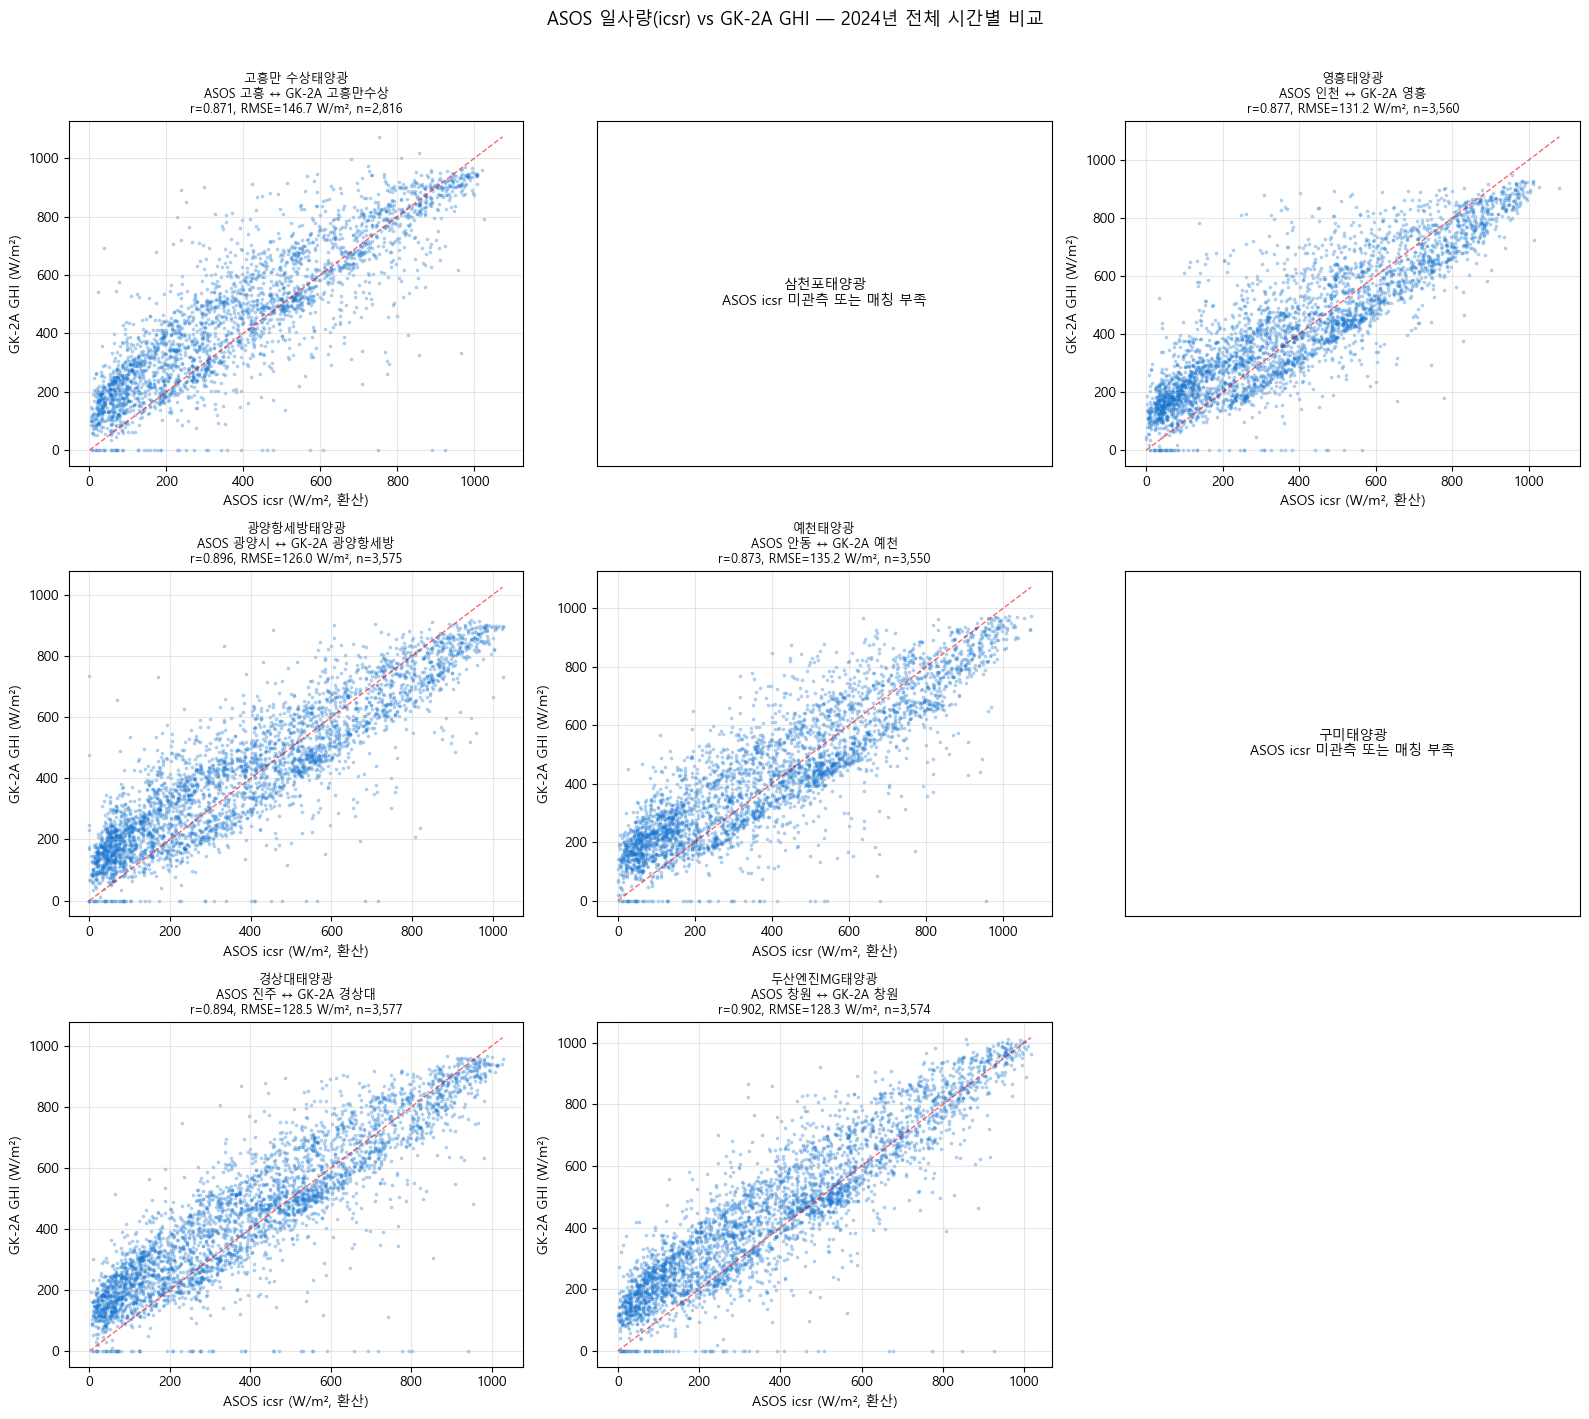

해석
  - r > 0.95: 두 소스가 매우 일관 → GK-2A 학습 데이터로 신뢰 가능
  - r < 0.9:  관측 환경 차이 (ASOS 관측소가 먼 경우)
  - RMSE: 절대 편차 크기 — GK-2A W/m² 순시 vs ASOS 시간적산의 구조적 차이 포함
  - 남해·구미는 ASOS icsr 미관측 → 매칭 불가 (삼천포·구미 사이트는 GK-2A 독점 필수)


In [ ]:
import glob, os

# ===== ASOS icsr vs GK-2A GHI — 같은 시각·같은 사이트 동시 비교 =====
# ASOS icsr: MJ/m² (시간적산)  → W/m² 환산: × 1000000 / 3600 ≈ × 277.78
# GK-2A DSR: W/m² (시간 평균)

# 사이트 → ASOS 매핑
SITE_TO_STN = {
    '고흥만 수상태양광':'고흥', '삼천포태양광':'남해', '영흥태양광':'인천',
    '영흥태양광#5':'인천', '광양항세방태양광':'광양시', '예천태양광':'안동',
    '구미태양광':'구미', '경상대태양광':'진주', '두산엔진MG태양광':'창원',
}
# 사이트 → GK-2A 컬럼
SITE_TO_GK2A = {
    '고흥만 수상태양광':'고흥만수상', '삼천포태양광':'삼천포', '영흥태양광':'영흥',
    '영흥태양광#5':'영흥', '광양항세방태양광':'광양항세방', '예천태양광':'예천',
    '구미태양광':'구미', '경상대태양광':'경상대', '두산엔진MG태양광':'창원',
}

# 2024년 전체 (가장 품질 안정)
asos_files = sorted(glob.glob('../../data/asos_hourly/asos_hourly_2024*.csv'))
asos_all = pd.concat([pd.read_csv(f) for f in asos_files], ignore_index=True)
asos_all['tm'] = pd.to_datetime(asos_all['tm'])
asos_all['icsr_wm2'] = asos_all['icsr'] * (1_000_000 / 3600)  # MJ/m²h → W/m²

ghi_files = sorted(glob.glob('../../data/gk2a_ghi/gk2a_ghi_2024*.csv'))
ghi_all = pd.concat([pd.read_csv(f) for f in ghi_files], ignore_index=True)
ghi_all['datetime_kst'] = pd.to_datetime(ghi_all['datetime_kst'])

# 사이트별 ASOS/GK-2A 페어 생성
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

common_sites = [
    ('고흥만 수상태양광','고흥','고흥만수상'),
    ('삼천포태양광','남해','삼천포'),
    ('영흥태양광','인천','영흥'),
    ('광양항세방태양광','광양시','광양항세방'),
    ('예천태양광','안동','예천'),
    ('구미태양광','구미','구미'),
    ('경상대태양광','진주','경상대'),
    ('두산엔진MG태양광','창원','창원'),
]

for i, (site_name, stn, gk2a_col) in enumerate(common_sites):
    ax = axes[i]
    a = asos_all[asos_all['stnNm'] == stn][['tm','icsr_wm2']].rename(columns={'tm':'t'})
    g = ghi_all[['datetime_kst', gk2a_col]].rename(columns={'datetime_kst':'t', gk2a_col:'ghi_gk2a'})
    m = a.merge(g, on='t', how='inner').dropna(subset=['icsr_wm2','ghi_gk2a'])
    if len(m) < 100:
        ax.text(0.5, 0.5, f'{site_name}\nASOS icsr 미관측 또는 매칭 부족', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    # 산점도
    ax.scatter(m['icsr_wm2'], m['ghi_gk2a'], s=3, alpha=0.25, color='#1976D2')
    # y=x 참조선
    mx = max(m['icsr_wm2'].max(), m['ghi_gk2a'].max())
    ax.plot([0, mx], [0, mx], 'r--', alpha=0.6, linewidth=1)
    r = m['icsr_wm2'].corr(m['ghi_gk2a'])
    rmse = np.sqrt(((m['icsr_wm2'] - m['ghi_gk2a'])**2).mean())
    ax.set_title(f'{site_name}\nASOS {stn} ↔ GK-2A {gk2a_col}\n'
                 f'r={r:.3f}, RMSE={rmse:.1f} W/m², n={len(m):,}', fontsize=9)
    ax.set_xlabel('ASOS icsr (W/m², 환산)')
    ax.set_ylabel('GK-2A GHI (W/m²)')
    ax.grid(True, alpha=0.3)

# 빈 셀 숨김
for j in range(len(common_sites), len(axes)):
    axes[j].axis('off')

plt.suptitle('ASOS 일사량(icsr) vs GK-2A GHI — 2024년 전체 시간별 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('해석')
print('  - r > 0.95: 두 소스가 매우 일관 → GK-2A 학습 데이터로 신뢰 가능')
print('  - r < 0.9:  관측 환경 차이 (ASOS 관측소가 먼 경우)')
print('  - RMSE: 절대 편차 크기 — GK-2A W/m² 순시 vs ASOS 시간적산의 구조적 차이 포함')
print('  - 남해·구미는 ASOS icsr 미관측 → 매칭 불가 (삼천포·구미 사이트는 GK-2A 독점 필수)')

---

## 📌 Stage 1 결정 로그 (채택/보류/폐기)

> EDA Plan v3.2 §7 원칙에 따라 노트북 말미에 고정 작성.

### 모델 의사결정 영향

| 항목 | 결론 | 근거 |
|---|---|---|
| 학습 대상 호기 | **11 호기 확정** (용량 77.3 MW) | §1 — data_strategy.md §2 (실데이터 피크 ≤15시 기준) |
| 포트폴리오 지배 구조 | **고흥만 82% + 10호기 18%** — 모델에서 이질성 처리 필요 | §2-1, §2-2 |
| 공통 계절성 | **(결과에 따라 채택/보류)** — 연도 overlay r ≥ 0.9면 1층 Fourier 정당 | §2-3 연도 overlay + §4 포트폴리오 CF |
| 호기별 재현성 | **r ≥ 0.9 호기는 per-unit 계절 고정 가능** | §3 호기별 CF overlay |
| 시간대 정책 | 07~18 기본 + 여름 19시 (data_strategy.md §4 0-fill 정책과 동기) | intro §구성 |

### 다음 단계 액션

1. **Stage 2 (노트북 02_variable_screening) — 신규 작성 예정**
   - ASOS 전수 변수(ta/hm/ws/wd/rn/pa/ps/ss/icsr/dc10Tca/dc10LmcsCa/ts) vs gen_kwh 상관
   - GK-2A `ghi` vs gen_kwh 상관 (기준선)
   - 피처 shortlist 확정
2. **Stage 3 (03/04/05) — 기존 노트북 재활용**
   - lag, 비선형 반응, 사이트 이질성, Source Sensitivity
3. **Phase 3 수집 완료 후 재실행** — Phase 3 `data/gk2a_v2/*.csv` 기반으로 Stage 1부터 Source 플래그 반영하여 전면 재실행

### 검토 필요 사항 (보류)

- 11 호기 선정 근거를 노트북에 재표기할지 (현재 `data_strategy.md §2` 참조로만 처리)
- 6시/18시/19시 경계 시간대 0-fill 적용이 overlay 지표에 미치는 영향 정량화
